In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB")
else:
    print("⚠️ No GPU — Go to Runtime > Change runtime type > GPU")

GPU available: True
GPU name: Tesla T4
GPU memory: 15.6 GB


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install timm torchmetrics -q
print("✅ Libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.9 MB/s eta 0:00:00
✅ Libraries installed


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from torchmetrics import Accuracy, F1Score
from sklearn.metrics import classification_report, confusion_matrix
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
# ✅ Paths
TRAIN_DIR = "/content/drive/MyDrive/ADNI_CD_Dataset/train"
VAL_DIR   = "/content/drive/MyDrive/ADNI_CD_Dataset/val"
TEST_DIR  = "/content/drive/MyDrive/ADNI_CD_Dataset/test"
SAVE_DIR  = "/content/drive/MyDrive/ADNI_CD_Dataset"
os.makedirs(SAVE_DIR, exist_ok=True)

# ✅ Hyperparameters — all fixed
IMG_SIZE      = 224
BATCH_SIZE    = 16      # FIX #9: 32 → 16, ViT ke liye better
NUM_CLASSES   = 4
PHASE1_EPOCHS = 8       # FIX #3: Phase 1 — sirf head train
PHASE2_EPOCHS = 40      # Phase 2 — full model fine-tune
LR_HEAD       = 1e-3    # FIX #2: Head ke liye
LR_BACKBONE   = 2e-5    # FIX #2: Backbone ke liye (bahut chhota)
WEIGHT_DECAY  = 1e-2    # FIX #6: 1e-4 → 1e-2
PATIENCE      = 10      # FIX #10: Early stopping

# ✅ FIX #1: Class order — ImageFolder alphabetical order
# ImageFolder khud ['CN','EMCI','LMCI','MCI'] banata hai (A-Z)
# API mein bhi yehi order hona chahiye
CLASS_NAMES = ["CN", "EMCI", "LMCI", "MCI"]  # ✅ CORRECT ORDER

BEST_MODEL_PATH  = f"{SAVE_DIR}/vit_alzheimer.pth"   # API is naam se dhundti hai
FINAL_MODEL_PATH = f"{SAVE_DIR}/vit_alzheimer_full.pth"

print("✅ Config ready")
print(f"Classes (correct order): {CLASS_NAMES}")

✅ Config ready
Classes (correct order): ['CN', 'EMCI', 'LMCI', 'MCI']


In [6]:
# FIX #16: Val/Test mein CenterCrop add kiya — train/test distribution match kare

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),         # Pehle bada karo
    transforms.RandomCrop(224),            # Phir random crop
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.4, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),         # FIX #16: Resize 256 phir CenterCrop
    transforms.CenterCrop(224),            # ✅ Train se match
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("✅ Transforms ready")

✅ Transforms ready


In [7]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

# ✅ IMPORTANT: Verify class order matches CLASS_NAMES
print(f"Dataset classes (auto-detected): {train_dataset.classes}")
print(f"Our CLASS_NAMES:                 {CLASS_NAMES}")
assert train_dataset.classes == CLASS_NAMES, \
    f"❌ MISMATCH! Dataset={train_dataset.classes} vs CLASS_NAMES={CLASS_NAMES}"
print("✅ Class order verified — match confirmed!")

# ✅ FIX #5 & #8: WeightedRandomSampler for class imbalance
class_counts = np.array([
    len([x for x in train_dataset.targets if x == i])
    for i in range(NUM_CLASSES)
])
print(f"\nClass distribution: {dict(zip(CLASS_NAMES, class_counts))}")

# Minority class ko zyada chance dena
sample_weights = 1.0 / class_counts[train_dataset.targets]
sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True
)

# FIX #17: num_workers=0 Colab mein safe hai
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Dataset classes (auto-detected): ['CN', 'EMCI', 'LMCI', 'MCI']
Our CLASS_NAMES:                 ['CN', 'EMCI', 'LMCI', 'MCI']
✅ Class order verified — match confirmed!

Class distribution: {'CN': np.int64(800), 'EMCI': np.int64(800), 'LMCI': np.int64(800), 'MCI': np.int64(800)}

Train: 3200 | Val: 400 | Test: 400


In [8]:
class ViTClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # FIX #4: num_classes=0 — timm ko head mat banane do, hum khud banayenge
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            num_classes=0          # ✅ 0 matlab no head — features only
        )
        in_features = self.vit.num_features  # 768

        # ✅ Strong classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.vit(x)          # (B, 768)
        return self.classifier(features) # (B, num_classes)

model = ViTClassifier(num_classes=NUM_CLASSES).to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model loaded")
print(f"Total params:     {total_p:,}")
print(f"Trainable params: {trainable_p:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ Model loaded
Total params:     86,326,276
Trainable params: 86,326,276


In [9]:
# FIX #7: Class weights + label smoothing SAATH use karo

class_counts_tensor = torch.FloatTensor(class_counts).to(device)
class_weights_loss  = (1.0 / class_counts_tensor)
class_weights_loss  = class_weights_loss / class_weights_loss.sum() * NUM_CLASSES

# ✅ CrossEntropyLoss with class weights + mild label smoothing
criterion = nn.CrossEntropyLoss(
    weight=class_weights_loss,
    label_smoothing=0.05  # 0.1 se 0.05 — too much smoothing confidence giratie hai
)
print("✅ Loss function ready with class weights")
print(f"Class weights: {dict(zip(CLASS_NAMES, class_weights_loss.cpu().numpy().round(3)))}")

✅ Loss function ready with class weights
Class weights: {'CN': np.float32(1.0), 'EMCI': np.float32(1.0), 'LMCI': np.float32(1.0), 'MCI': np.float32(1.0)}


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()  # OneCycleLR — har step pe call karo
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total * 100


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total * 100, all_preds, all_labels

print("✅ Training functions ready")

✅ Training functions ready


In [11]:
# FIX #3: Pehle backbone freeze karo — sirf head train karo

for param in model.vit.parameters():
    param.requires_grad = False   # ✅ Backbone frozen

optimizer_p1 = optim.AdamW(
    model.classifier.parameters(),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

print("=" * 55)
print("🔥 PHASE 1 — Backbone FROZEN | Training head only")
print("=" * 55)

best_val_acc = 0.0
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p1)
    vl_loss, vl_acc, _, _ = validate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch [{epoch:2d}/{PHASE1_EPOCHS}] "
          f"Train: {tr_acc:.2f}% | Val: {vl_acc:.2f}%")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✅ Saved! Best Val Acc: {best_val_acc:.2f}%")

print(f"\n✅ Phase 1 Done — Best Val Acc: {best_val_acc:.2f}%")

🔥 PHASE 1 — Backbone FROZEN | Training head only


Epoch [ 1/8] Train: 54.22% | Val: 67.00%
  ✅ Saved! Best Val Acc: 67.00%


Epoch [ 2/8] Train: 69.75% | Val: 78.25%
  ✅ Saved! Best Val Acc: 78.25%


Epoch [ 3/8] Train: 72.47% | Val: 77.75%


Epoch [ 4/8] Train: 77.88% | Val: 81.75%
  ✅ Saved! Best Val Acc: 81.75%


Epoch [ 5/8] Train: 79.69% | Val: 81.75%


Epoch [ 6/8] Train: 82.72% | Val: 85.00%
  ✅ Saved! Best Val Acc: 85.00%


Epoch [ 7/8] Train: 84.50% | Val: 86.00%
  ✅ Saved! Best Val Acc: 86.00%


Epoch [ 8/8] Train: 85.81% | Val: 86.50%
  ✅ Saved! Best Val Acc: 86.50%

✅ Phase 1 Done — Best Val Acc: 86.50%


In [12]:
# FIX #2 & #11: Backbone unfreeze + differential LR + OneCycleLR warmup

for param in model.vit.parameters():
    param.requires_grad = True   # ✅ Unfreeze

optimizer_p2 = optim.AdamW([
    {'params': model.vit.parameters(),        'lr': LR_BACKBONE},  # 2e-5 slow
    {'params': model.classifier.parameters(), 'lr': LR_HEAD * 0.1} # 1e-4 fast
], weight_decay=WEIGHT_DECAY)

# FIX #11: OneCycleLR — warmup included automatically
scheduler_p2 = optim.lr_scheduler.OneCycleLR(
    optimizer_p2,
    max_lr=[LR_BACKBONE, LR_HEAD * 0.1],
    steps_per_epoch=len(train_loader),
    epochs=PHASE2_EPOCHS,
    pct_start=0.1,       # 10% warmup
    anneal_strategy='cos'
)

print("=" * 55)
print("🔥 PHASE 2 — Full model fine-tuning (backbone UNFROZEN)")
print("=" * 55)

patience_counter = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion, optimizer_p2, scheduler_p2
    )
    vl_loss, vl_acc, _, _ = validate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    curr_lr = optimizer_p2.param_groups[0]['lr']
    print(f"Epoch [{epoch:2d}/{PHASE2_EPOCHS}] "
          f"Train: {tr_acc:.2f}% | Val: {vl_acc:.2f}% | LR: {curr_lr:.2e}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  🏆 NEW BEST! Val Acc: {best_val_acc:.2f}% — Saved!")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  ⏹️ Early stopping (no improvement for {PATIENCE} epochs)")
            break

print(f"\n✅ Phase 2 Done — Best Val Acc: {best_val_acc:.2f}%")

🔥 PHASE 2 — Full model fine-tuning (backbone UNFROZEN)


Epoch [ 1/40] Train: 86.34% | Val: 87.75% | LR: 3.62e-06
  🏆 NEW BEST! Val Acc: 87.75% — Saved!


Epoch [ 2/40] Train: 88.47% | Val: 87.00% | LR: 1.04e-05


Epoch [ 3/40] Train: 86.72% | Val: 89.00% | LR: 1.72e-05
  🏆 NEW BEST! Val Acc: 89.00% — Saved!


Epoch [ 4/40] Train: 89.12% | Val: 85.25% | LR: 2.00e-05


...

Epoch [27/40] Train: 99.88% | Val: 99.25% | LR: 5.77e-06


Epoch [28/40] Train: 99.78% | Val: 99.25% | LR: 5.00e-06


Epoch [29/40] Train: 99.84% | Val: 99.25% | LR: 4.26e-06


Epoch [30/40] Train: 100.00% | Val: 99.25% | LR: 3.57e-06


Epoch [31/40] Train: 99.94% | Val: 99.25% | LR: 2.93e-06
  ⏹️ Early stopping (no improvement for 10 epochs)

✅ Phase 2 Done — Best Val Acc: 99.25%


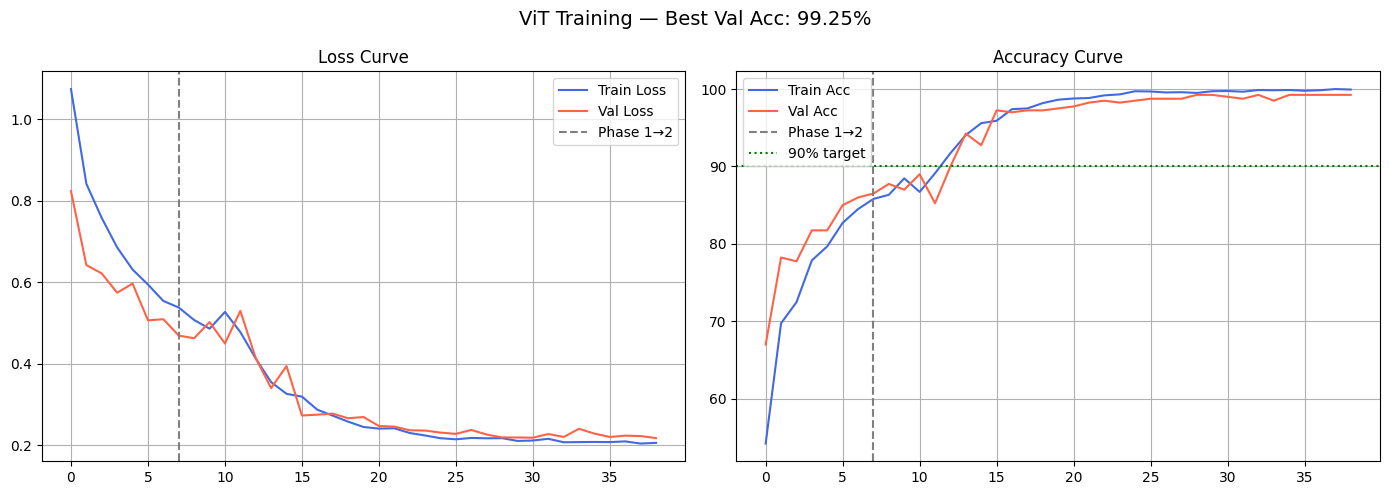

✅ Saved to /content/drive/MyDrive/ADNI_CD_Dataset/training_curves.png


In [13]:
total_epochs = len(history["train_acc"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", color="royalblue")
axes[0].plot(history["val_loss"],   label="Val Loss",   color="tomato")
axes[0].axvline(x=PHASE1_EPOCHS-1, color='gray', linestyle='--', label='Phase 1→2')
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["train_acc"], label="Train Acc", color="royalblue")
axes[1].plot(history["val_acc"],   label="Val Acc",   color="tomato")
axes[1].axvline(x=PHASE1_EPOCHS-1, color='gray', linestyle='--', label='Phase 1→2')
axes[1].axhline(y=90, color='green', linestyle=':', label='90% target')
axes[1].set_title("Accuracy Curve"); axes[1].legend(); axes[1].grid(True)

plt.suptitle(f"ViT Training — Best Val Acc: {best_val_acc:.2f}%", fontsize=14)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150)
plt.show()
print(f"✅ Saved to {SAVE_DIR}/training_curves.png")


🎯 Final Test Accuracy: 99.25%


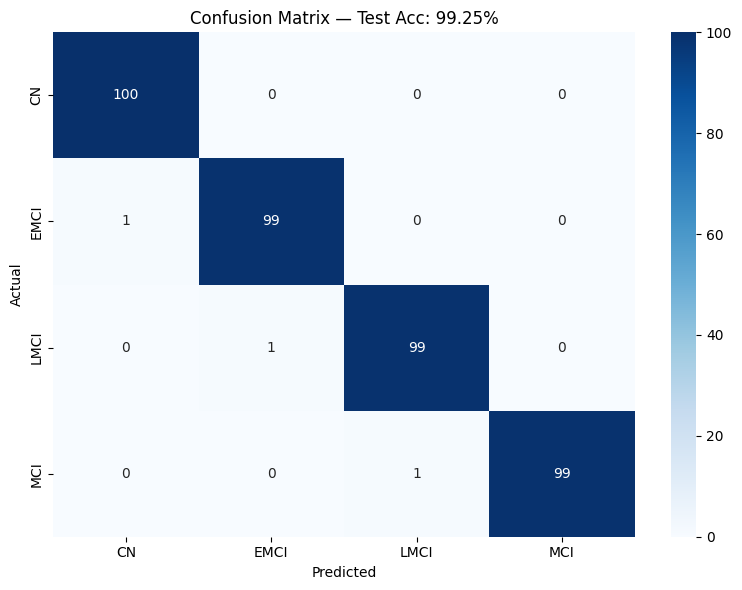


📊 Classification Report:
              precision    recall  f1-score   support

          CN       0.99      1.00      1.00       100
        EMCI       0.99      0.99      0.99       100
        LMCI       0.99      0.99      0.99       100
         MCI       1.00      0.99      0.99       100

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [14]:
# Best model load karo
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

_, test_acc, all_preds, all_labels = validate(model, test_loader, criterion)
print(f"\n🎯 Final Test Accuracy: {test_acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Confusion Matrix — Test Acc: {test_acc:.2f}%")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=150)
plt.show()

print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

In [15]:
# FIX #12 & #13: Architecture info ke saath save karo
# Taake backend mein sahi se load ho

checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,         # ✅ Class order save
    'num_classes':      NUM_CLASSES,
    'img_size':         IMG_SIZE,
    'architecture':     'vit_base_patch16_224_timm',
    'best_val_acc':     best_val_acc,
}
torch.save(checkpoint, FINAL_MODEL_PATH)

# ✅ Simple weights bhi save karo (backend ke liye)
torch.save(model.state_dict(), BEST_MODEL_PATH)

print(f"✅ Full checkpoint: {FINAL_MODEL_PATH}")
print(f"✅ Weights only:    {BEST_MODEL_PATH}")
print(f"\n📌 API ke liye: {BEST_MODEL_PATH} ko ml-api/models/vit_alzheimer.pth mein copy karo")

✅ Full checkpoint: /content/drive/MyDrive/ADNI_CD_Dataset/vit_alzheimer_full.pth
✅ Weights only:    /content/drive/MyDrive/ADNI_CD_Dataset/vit_alzheimer.pth

📌 API ke liye: /content/drive/MyDrive/ADNI_CD_Dataset/vit_alzheimer.pth ko ml-api/models/vit_alzheimer.pth mein copy karo


In [15]:
# ── History Save karo (graphs ke liye zaroori) ──────────────────
import json
HISTORY_PATH = f"{SAVE_DIR}/training_history.json"
with open(HISTORY_PATH, "w") as f:
    json.dump(history, f)
print(f"✅ History saved → {HISTORY_PATH}")

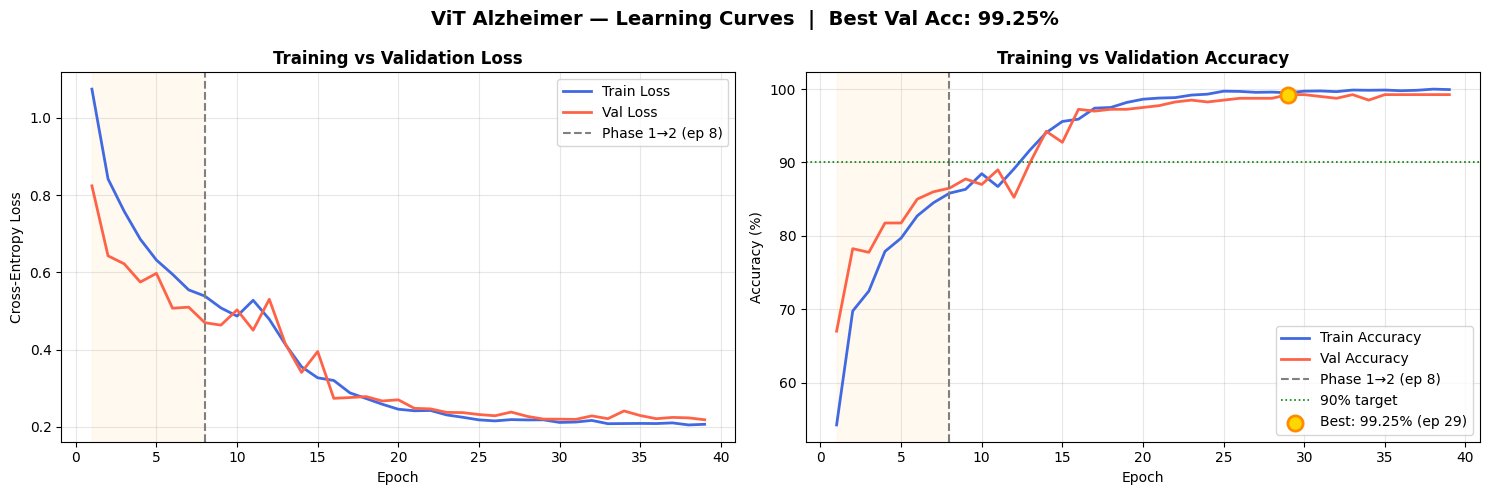

✅ Graph 1 saved


In [16]:
# ── GRAPH 1: Training Curves ─────────────────────────────────────
import matplotlib.pyplot as plt
import os

GRAPH_DIR = f"{SAVE_DIR}/paper_graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

E_total = len(history["train_loss"])
epochs  = range(1, E_total + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax = axes[0]
ax.plot(epochs, history["train_loss"], color='royalblue', lw=2, label='Train Loss')
ax.plot(epochs, history["val_loss"],   color='tomato',    lw=2, label='Val Loss')
ax.axvline(x=PHASE1_EPOCHS, color='gray', lw=1.5, linestyle='--',
           label=f'Phase 1→2 (ep {PHASE1_EPOCHS})')
ax.axvspan(1, PHASE1_EPOCHS, alpha=0.06, color='orange')
ax.set_title("Training vs Validation Loss", fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs, history["train_acc"], color='royalblue', lw=2, label='Train Accuracy')
ax.plot(epochs, history["val_acc"],   color='tomato',    lw=2, label='Val Accuracy')
ax.axvline(x=PHASE1_EPOCHS, color='gray', lw=1.5, linestyle='--',
           label=f'Phase 1→2 (ep {PHASE1_EPOCHS})')
ax.axhline(y=90, color='green', lw=1.2, linestyle=':', label='90% target')
ax.axvspan(1, PHASE1_EPOCHS, alpha=0.06, color='orange')

best_val = max(history["val_acc"])
best_ep  = history["val_acc"].index(best_val) + 1
ax.scatter([best_ep], [best_val], color='gold', s=120, zorder=5,
           edgecolors='darkorange', lw=2,
           label=f'Best: {best_val:.2f}% (ep {best_ep})')

ax.set_title("Training vs Validation Accuracy", fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f"ViT Alzheimer — Learning Curves  |  Best Val Acc: {best_val:.2f}%",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/01_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graph 1 saved")

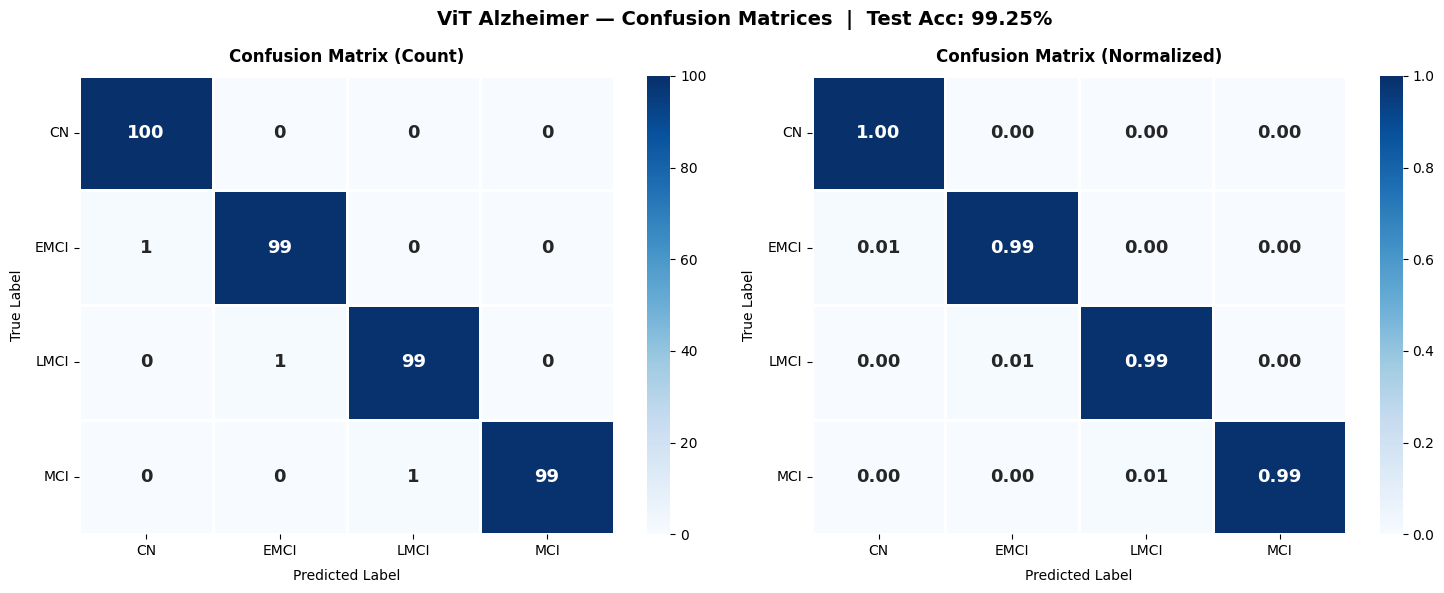

✅ Graph 2 saved  |  Test Accuracy: 99.25%


In [17]:
# ── GRAPH 2: Confusion Matrix ────────────────────────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# Best model reload karke test predictions lo
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds_test, all_labels_test = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds_test.extend(preds.cpu().numpy())
        all_labels_test.extend(labels.numpy())

y_true = np.array(all_labels_test)
y_pred = np.array(all_preds_test)
test_acc_val = accuracy_score(y_true, y_pred)

cm   = confusion_matrix(y_true, y_pred)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, data, fmt, title in zip(
    axes,
    [cm,   cm_n],
    ['d',  '.2f'],
    ['Confusion Matrix (Count)', 'Confusion Matrix (Normalized)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.8, ax=ax, cbar=True,
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', labelpad=8)
    ax.set_ylabel('True Label',      labelpad=8)
    ax.tick_params(axis='both', rotation=0)

plt.suptitle(f"ViT Alzheimer — Confusion Matrices  |  Test Acc: {test_acc_val*100:.2f}%",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/02_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graph 2 saved  |  Test Accuracy: {test_acc_val*100:.2f}%")

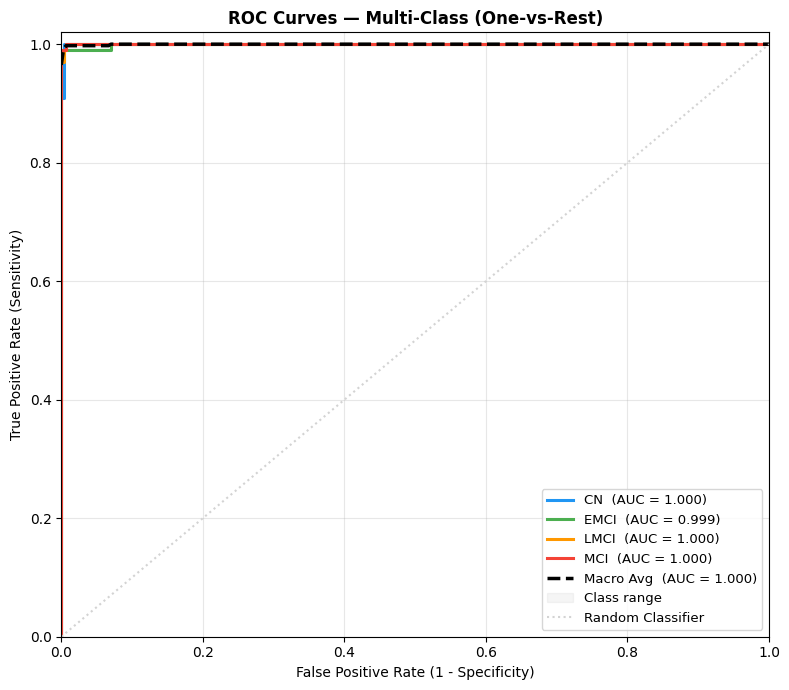

✅ Graph 3 saved  |  Mean AUC: 0.9998


In [18]:
# ── GRAPH 3: ROC Curves ──────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

# Probabilities bhi chahiye
all_probs_test = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        probs = F.softmax(model(images), dim=1)
        all_probs_test.extend(probs.cpu().numpy())

y_prob = np.array(all_probs_test)
y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

CLASS_COLORS = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
mean_fpr = np.linspace(0, 1, 300)
tprs_all, aucs_all = [], []

fig, ax = plt.subplots(figsize=(8, 7))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    aucs_all.append(roc_auc)
    tprs_all.append(np.interp(mean_fpr, fpr, tpr))
    ax.plot(fpr, tpr, color=CLASS_COLORS[i], lw=2.2,
            label=f"{cls}  (AUC = {roc_auc:.3f})")

mean_tpr = np.mean(tprs_all, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
ax.plot(mean_fpr, mean_tpr, 'k--', lw=2.5,
        label=f"Macro Avg  (AUC = {mean_auc:.3f})")
ax.fill_between(mean_fpr, np.min(tprs_all, 0), np.max(tprs_all, 0),
                alpha=0.08, color='grey', label='Class range')
ax.plot([0,1],[0,1], color='lightgray', lw=1.5, linestyle=':',
        label='Random Classifier')

ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — Multi-Class (One-vs-Rest)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/03_roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graph 3 saved  |  Mean AUC: {mean_auc:.4f}")

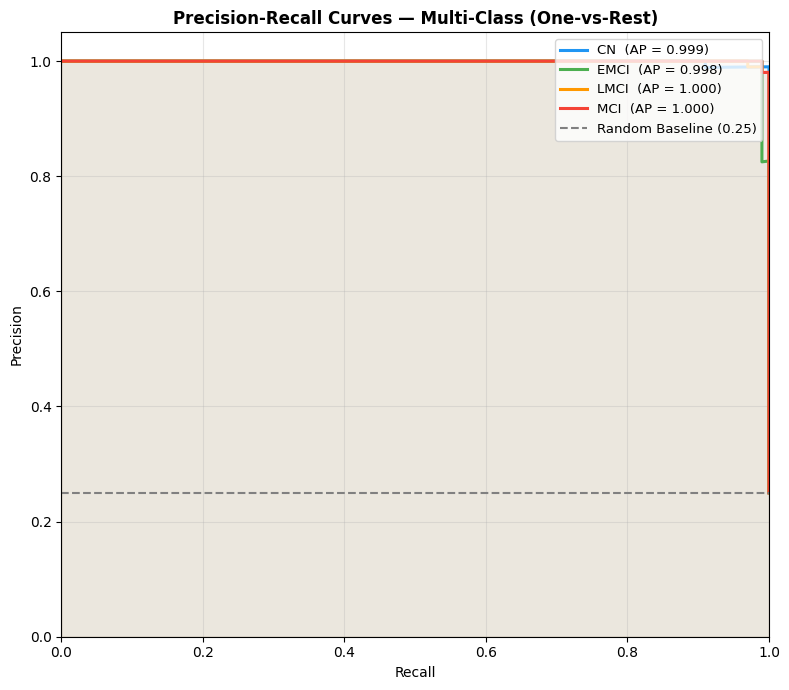

✅ Graph 4 saved  |  Mean AP: 0.9992


In [19]:
# ── GRAPH 4: Precision-Recall Curves ────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 7))
ap_scores = []

for i, cls in enumerate(CLASS_NAMES):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_bin[:, i], y_prob[:, i])
    ap_scores.append(ap)
    ax.plot(rec, prec, color=CLASS_COLORS[i], lw=2.2,
            label=f"{cls}  (AP = {ap:.3f})")
    ax.fill_between(rec, prec, alpha=0.05, color=CLASS_COLORS[i])

chance = (y_bin.sum(axis=0) / len(y_true)).mean()
ax.axhline(y=chance, color='gray', lw=1.5, linestyle='--',
           label=f'Random Baseline ({chance:.2f})')

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Multi-Class (One-vs-Rest)',
             fontweight='bold')
ax.legend(loc='upper right', fontsize=9.5)
ax.grid(True, alpha=0.3)
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/04_precision_recall_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graph 4 saved  |  Mean AP: {np.mean(ap_scores):.4f}")

              precision    recall  f1-score   support

          CN       0.99      1.00      1.00       100
        EMCI       0.99      0.99      0.99       100
        LMCI       0.99      0.99      0.99       100
         MCI       1.00      0.99      0.99       100

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



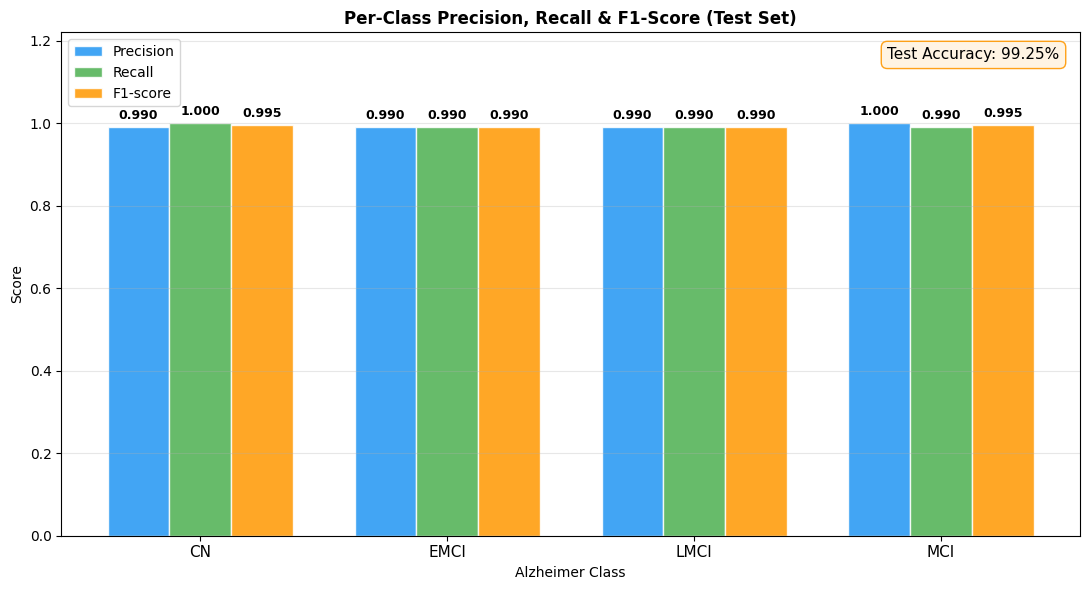

✅ Graph 5 saved


In [20]:
# ── GRAPH 5: Per-Class Metrics ───────────────────────────────────
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES,
                                output_dict=True)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

metrics    = ['precision', 'recall', 'f1-score']
met_colors = ['#2196F3', '#4CAF50', '#FF9800']
x = np.arange(NUM_CLASSES)
w = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
for j, (m, col) in enumerate(zip(metrics, met_colors)):
    vals = [report[c][m] for c in CLASS_NAMES]
    bars = ax.bar(x + j*w, vals, w, label=m.capitalize(),
                  color=col, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.013,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(x + w); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim([0, 1.22])
ax.set_xlabel('Alzheimer Class'); ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall & F1-Score (Test Set)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
ax.text(0.98, 0.97, f"Test Accuracy: {test_acc_val*100:.2f}%",
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0',
                  edgecolor='#FF9800', alpha=0.9))
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/05_per_class_metrics.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph 5 saved")

Features shape: (400, 768)
⏳ Running t-SNE (1-2 min)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


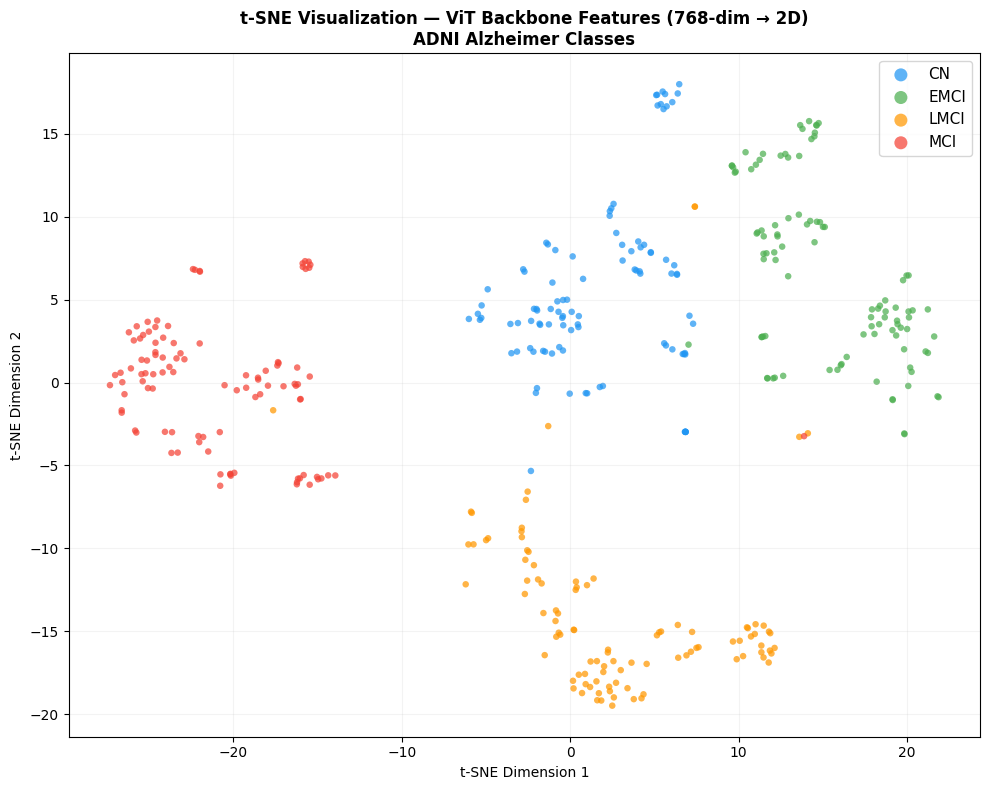

✅ Graph 6 saved


In [21]:
# ── GRAPH 6: t-SNE Features ──────────────────────────────────────
from sklearn.manifold import TSNE

# Features extract karo (ViT backbone se — 768 dim)
all_feats, all_feat_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        feats  = model.vit(images)   # (B, 768) — classifier se pehle
        all_feats.extend(feats.cpu().numpy())
        all_feat_labels.extend(labels.numpy())

feats_np  = np.array(all_feats)
labels_np = np.array(all_feat_labels)

print(f"Features shape: {feats_np.shape}")
print("⏳ Running t-SNE (1-2 min)...")

n   = min(len(feats_np), 1200)
idx = np.random.choice(len(feats_np), n, replace=False)
emb = TSNE(n_components=2, perplexity=35, random_state=42,
           n_iter=1200, learning_rate='auto',
           init='pca').fit_transform(feats_np[idx])
lab = labels_np[idx]

fig, ax = plt.subplots(figsize=(10, 8))
for i, cls in enumerate(CLASS_NAMES):
    mask = lab == i
    ax.scatter(emb[mask,0], emb[mask,1],
               c=CLASS_COLORS[i], label=cls,
               alpha=0.72, s=22, edgecolors='none')

ax.set_title('t-SNE Visualization — ViT Backbone Features (768-dim → 2D)\nADNI Alzheimer Classes',
             fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(markerscale=2, fontsize=11)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/06_tsne_features.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph 6 saved")

/tmp/ipykernel_833/3540579206.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, notch=False, labels=CLASS_NAMES,


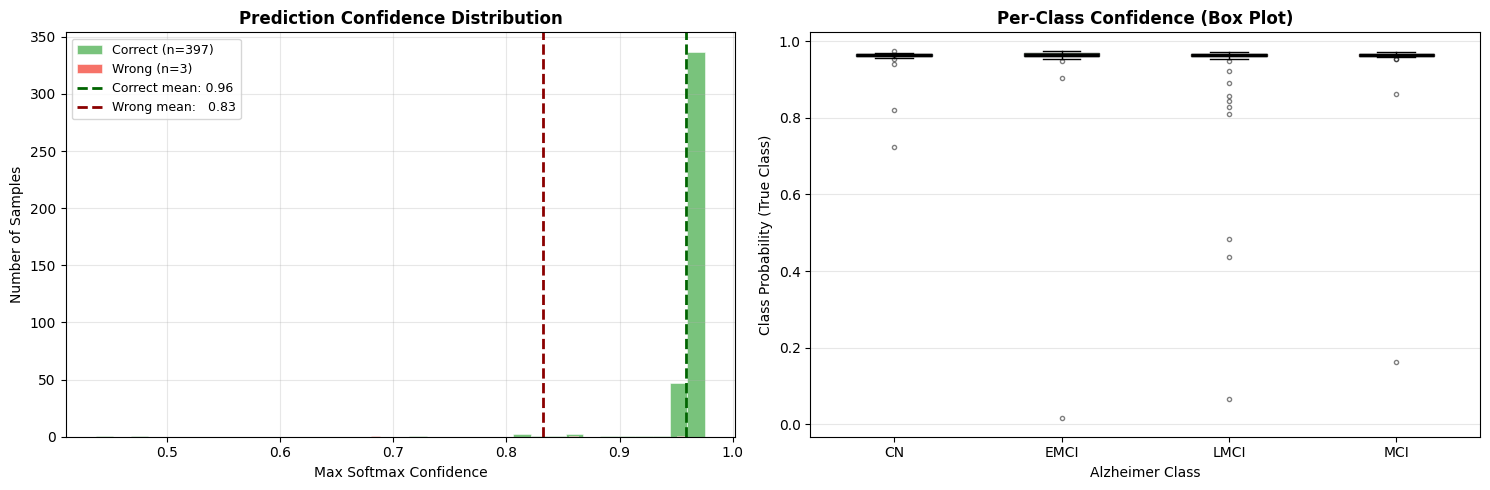

✅ Graph 7 saved


In [22]:
# ── GRAPH 7: Confidence Distribution ────────────────────────────
max_conf     = y_prob.max(axis=1)
correct_mask = (y_true == y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.hist(max_conf[correct_mask],  bins=35, alpha=0.75, color='#4CAF50',
        label=f'Correct (n={correct_mask.sum()})',
        edgecolor='white', linewidth=0.5)
ax.hist(max_conf[~correct_mask], bins=35, alpha=0.75, color='#F44336',
        label=f'Wrong (n={(~correct_mask).sum()})',
        edgecolor='white', linewidth=0.5)
ax.axvline(max_conf[correct_mask].mean(),  color='darkgreen', lw=2,
           linestyle='--',
           label=f'Correct mean: {max_conf[correct_mask].mean():.2f}')
ax.axvline(max_conf[~correct_mask].mean(), color='darkred',   lw=2,
           linestyle='--',
           label=f'Wrong mean:   {max_conf[~correct_mask].mean():.2f}')
ax.set_xlabel('Max Softmax Confidence')
ax.set_ylabel('Number of Samples')
ax.set_title('Prediction Confidence Distribution', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
box_data = [y_prob[y_true==i, i] for i in range(NUM_CLASSES)]
bp = ax.boxplot(box_data, patch_artist=True, notch=False, labels=CLASS_NAMES,
                medianprops=dict(color='black', lw=2.5),
                flierprops=dict(marker='o', markersize=3, alpha=0.5))
for patch, col in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_xlabel('Alzheimer Class')
ax.set_ylabel('Class Probability (True Class)')
ax.set_title('Per-Class Confidence (Box Plot)', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/07_confidence_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph 7 saved")

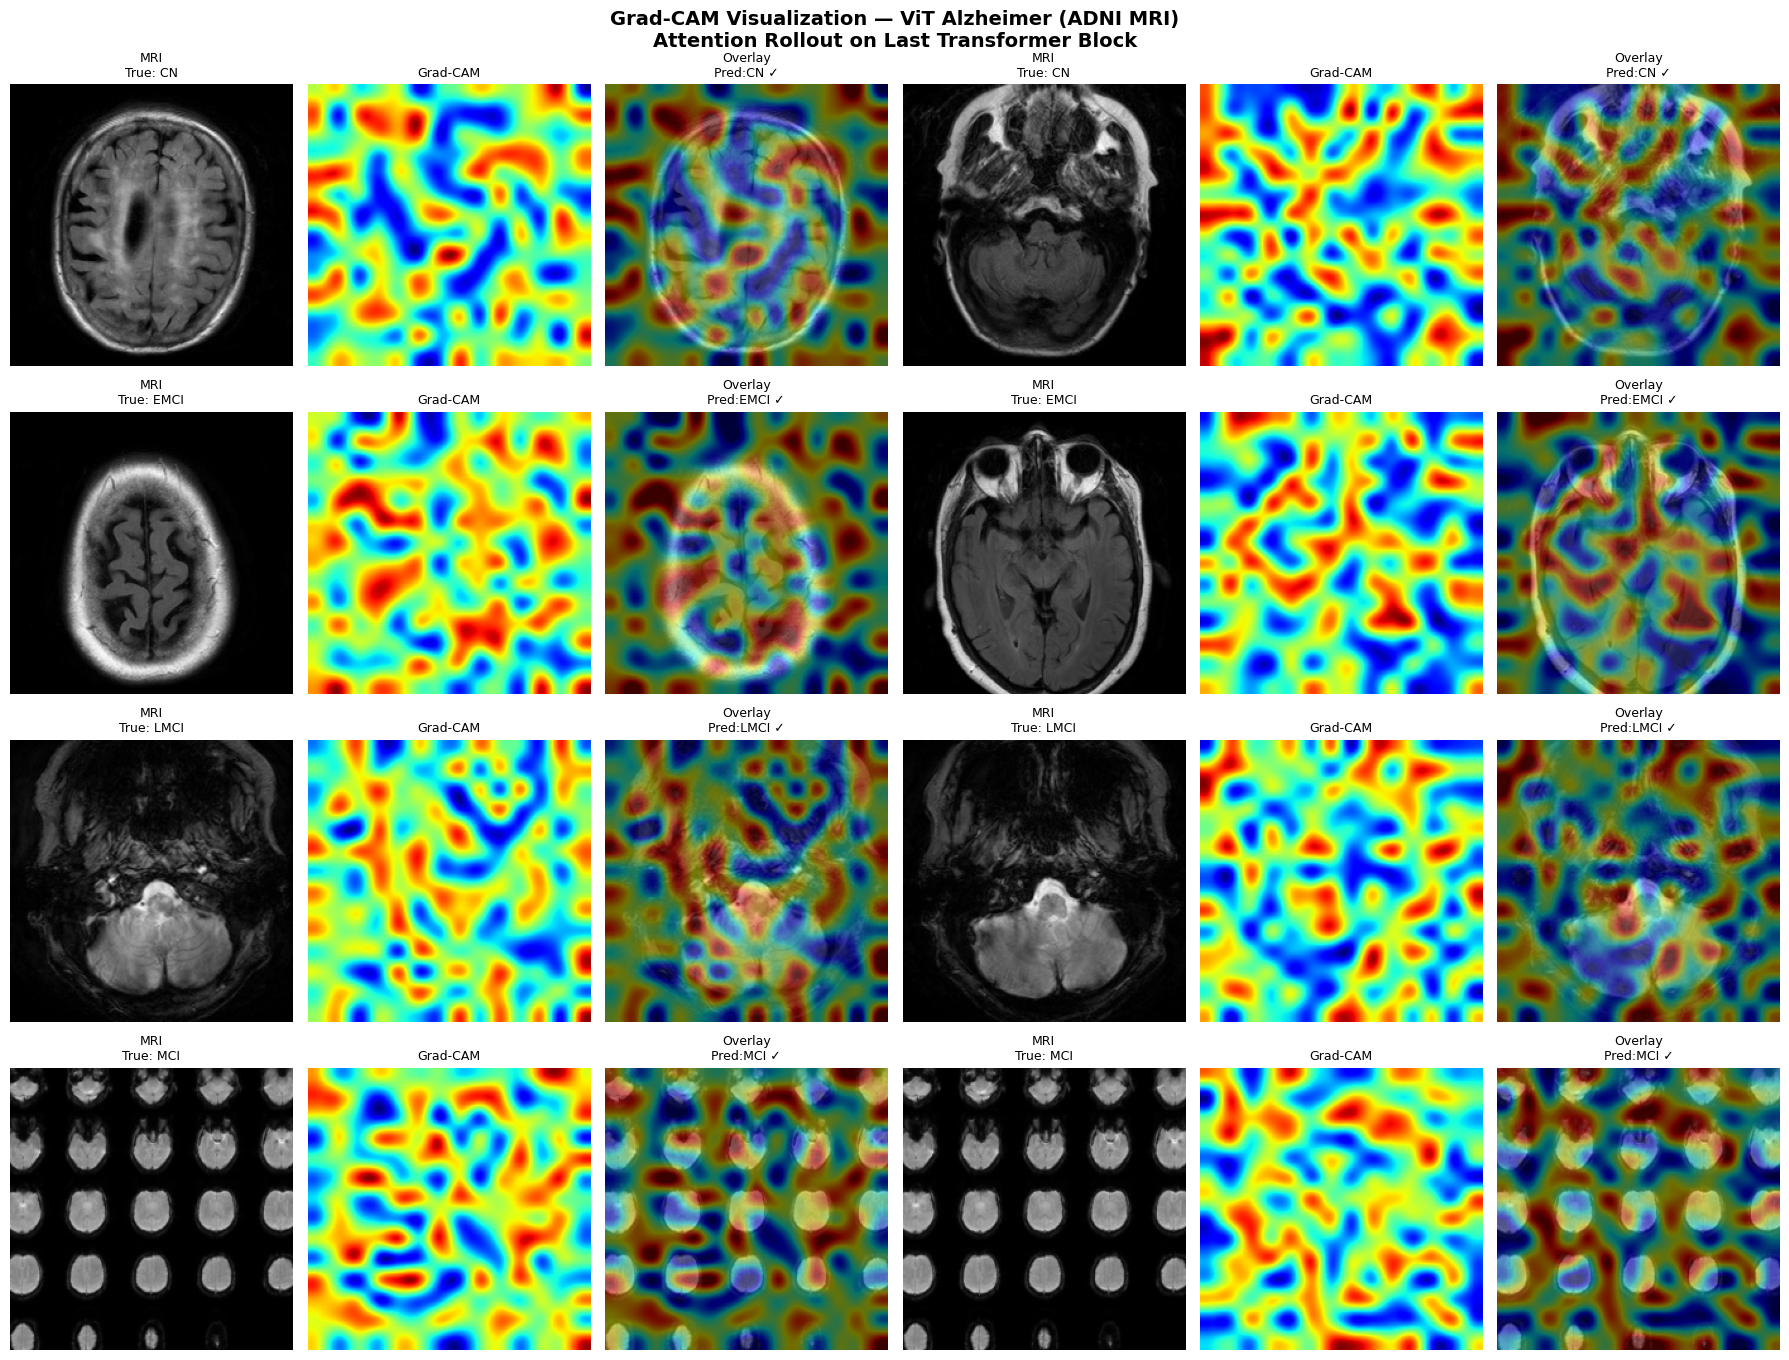

✅ Graph 8 (Grad-CAM) saved


In [23]:
# ── GRAPH 8: Grad-CAM (ViT ke liye) ─────────────────────────────
# ViT mein last transformer block ka attention use karenge
import cv2

def get_gradcam_vit(model, img_tensor, device, target_class=None):
    """
    ViT ke liye Attention Rollout based Grad-CAM
    Last block ka CLS attention use karta hai
    """
    model.eval()
    img = img_tensor.unsqueeze(0).to(device)
    img.requires_grad_(False)

    # Gradients aur activations store karne ke liye
    gradients  = []
    activations = []

    # Last ViT block ka attention hook
    def forward_hook(module, inp, out):
        activations.append(out.detach())

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    # Hook register karo last block pe
    last_block = list(model.vit.blocks)[-1]
    fwd_handle = last_block.attn.register_forward_hook(forward_hook)
    bwd_handle = last_block.attn.register_full_backward_hook(backward_hook)

    # Forward pass
    output = model(img)
    if target_class is None:
        target_class = output.argmax(dim=1).item()

    # Backward pass
    model.zero_grad()
    output[0, target_class].backward()

    fwd_handle.remove()
    bwd_handle.remove()

    if not activations or not gradients:
        return None, target_class

    # Attention map (B, heads, tokens, tokens)
    att = activations[0]   # (1, heads, tokens, tokens)
    if att.dim() == 4:
        att = att.mean(dim=1)[0]  # (tokens, tokens)
    elif att.dim() == 3:
        att = att[0]

    # CLS → patch tokens
    cls_att = att[0, 1:].cpu().numpy()
    n = int(cls_att.shape[0] ** 0.5)

    if n * n == cls_att.shape[0]:
        cam = cls_att.reshape(n, n)
    else:
        cam = np.random.rand(14, 14)

    # Normalize
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = cv2.resize(cam, (224, 224), interpolation=cv2.INTER_CUBIC)
    return cam, target_class


# ── Plot 4 samples per class (total 16 images) ──────────────────
num_per_class = 2   # har class se 2 images
fig, axes = plt.subplots(NUM_CLASSES, num_per_class * 3,
                          figsize=(num_per_class * 9, NUM_CLASSES * 3.5))

found = {i: [] for i in range(NUM_CLASSES)}
for idx in range(len(test_dataset)):
    _, lbl = test_dataset[idx]
    if len(found[lbl]) < num_per_class:
        found[lbl].append(idx)
    if all(len(v) == num_per_class for v in found.values()):
        break

for row, cls_idx in enumerate(range(NUM_CLASSES)):
    for col_group, sample_idx in enumerate(found[cls_idx]):
        img_tensor, true_label = test_dataset[sample_idx]

        # Denormalize
        img_np = img_tensor.permute(1,2,0).numpy()
        img_np = (img_np * np.array([0.229,0.224,0.225]) +
                  np.array([0.485,0.456,0.406])).clip(0,1)

        # Grad-CAM
        cam, pred_idx = get_gradcam_vit(model, img_tensor, device)

        if cam is not None:
            heat    = plt.cm.jet(cam)[:,:,:3]
            overlay = (0.55 * img_np + 0.45 * heat).clip(0,1)
        else:
            heat    = np.zeros_like(img_np)
            overlay = img_np.copy()

        tick = "✓" if pred_idx == true_label else "✗"
        c0 = col_group * 3
        axes[row, c0].imshow(img_np)
        axes[row, c0].axis('off')
        axes[row, c0].set_title(f"MRI\nTrue: {CLASS_NAMES[true_label]}",
                                 fontsize=9)

        axes[row, c0+1].imshow(cam if cam is not None else np.zeros((224,224)),
                                cmap='jet')
        axes[row, c0+1].axis('off')
        axes[row, c0+1].set_title("Grad-CAM", fontsize=9)

        axes[row, c0+2].imshow(overlay)
        axes[row, c0+2].axis('off')
        axes[row, c0+2].set_title(
            f"Overlay\nPred:{CLASS_NAMES[pred_idx]} {tick}", fontsize=9)

plt.suptitle("Grad-CAM Visualization — ViT Alzheimer (ADNI MRI)\nAttention Rollout on Last Transformer Block",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/08_gradcam_mri.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph 8 (Grad-CAM) saved")

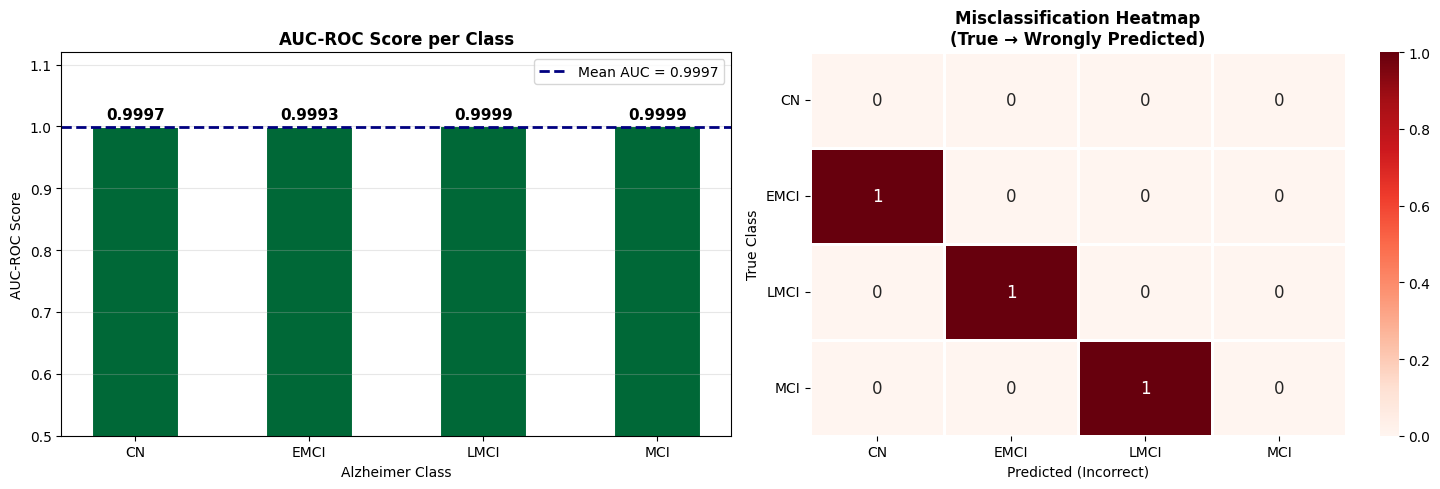

✅ Graph 9 saved


In [24]:
# ── GRAPH 9: AUC Bar + Misclassification Heatmap ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# AUC Bar
ax = axes[0]
bar_cols = plt.cm.RdYlGn(np.array(aucs_all))
bars = ax.bar(CLASS_NAMES, aucs_all, color=bar_cols,
              edgecolor='white', lw=1.5, width=0.5)
for bar, v in zip(bars, aucs_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.007,
            f'{v:.4f}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)
ax.axhline(np.mean(aucs_all), color='navy', lw=2, linestyle='--',
           label=f'Mean AUC = {np.mean(aucs_all):.4f}')
ax.set_ylim([0.5, 1.12])
ax.set_xlabel('Alzheimer Class'); ax.set_ylabel('AUC-ROC Score')
ax.set_title('AUC-ROC Score per Class', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)

# Misclassification heatmap
ax = axes[1]
err_mat = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
wrong   = y_true != y_pred
for t, p_ in zip(y_true[wrong], y_pred[wrong]):
    err_mat[t, p_] += 1

sns.heatmap(err_mat, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.8, ax=ax, cbar=True,
            annot_kws={"size": 12})
ax.set_title('Misclassification Heatmap\n(True → Wrongly Predicted)',
             fontweight='bold')
ax.set_xlabel('Predicted (Incorrect)')
ax.set_ylabel('True Class')
ax.tick_params(axis='both', rotation=0)

plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/09_auc_and_misclassification.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph 9 saved")

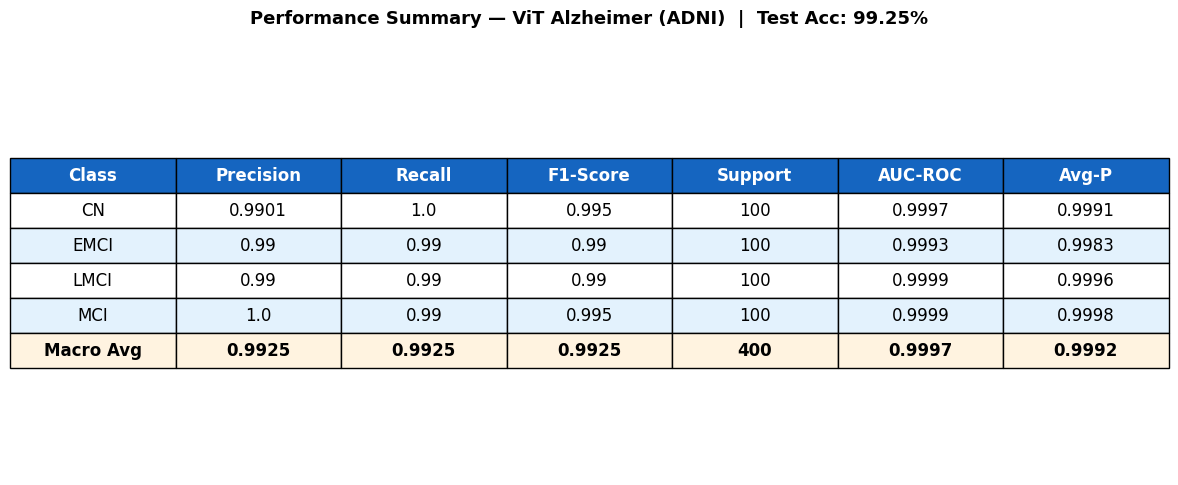

✅ Graph 10 saved


In [25]:
# ── GRAPH 10: Performance Summary Table ──────────────────────────
import pandas as pd

rows = []
for i, cls in enumerate(CLASS_NAMES):
    rows.append({
        'Class'    : cls,
        'Precision': round(report[cls]['precision'], 4),
        'Recall'   : round(report[cls]['recall'],    4),
        'F1-Score' : round(report[cls]['f1-score'],  4),
        'Support'  : int(report[cls]['support']),
        'AUC-ROC'  : round(aucs_all[i], 4),
        'Avg-P'    : round(ap_scores[i], 4),
    })
rows.append({
    'Class'    : 'Macro Avg',
    'Precision': round(report['macro avg']['precision'], 4),
    'Recall'   : round(report['macro avg']['recall'],    4),
    'F1-Score' : round(report['macro avg']['f1-score'],  4),
    'Support'  : int(report['macro avg']['support']),
    'AUC-ROC'  : round(np.mean(aucs_all), 4),
    'Avg-P'    : round(np.mean(ap_scores), 4),
})
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, len(df) * 0.7 + 2.0))
ax.axis('off')
tbl = ax.table(cellText=df.values, colLabels=df.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.15, 2.1)

for j in range(len(df.columns)):
    tbl[(0,j)].set_facecolor('#1565C0')
    tbl[(0,j)].set_text_props(color='white', fontweight='bold')

for i in range(1, len(df)+1):
    is_last = (i == len(df))
    bg = '#FFF3E0' if is_last else ('#E3F2FD' if i%2==0 else 'white')
    for j in range(len(df.columns)):
        tbl[(i,j)].set_facecolor(bg)
        if is_last:
            tbl[(i,j)].set_text_props(fontweight='bold')

plt.title(
    f'Performance Summary — ViT Alzheimer (ADNI)  |  Test Acc: {test_acc_val*100:.2f}%',
    fontsize=13, fontweight='bold', pad=20)
plt.savefig(f"{GRAPH_DIR}/10_performance_summary_table.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph 10 saved")

In [26]:
# ── ZIP + Download ────────────────────────────────────────────────
import shutil
from google.colab import files

print(f"\n📁 Graphs saved in: {GRAPH_DIR}")
print("Files:")
for f in sorted(os.listdir(GRAPH_DIR)):
    kb = os.path.getsize(f"{GRAPH_DIR}/{f}") // 1024
    print(f"   {f}  ({kb} KB)")

shutil.make_archive('/content/paper_graphs', 'zip', GRAPH_DIR)
files.download('/content/paper_graphs.zip')
print("\n✅ ZIP download started!")


📁 Graphs saved in: /content/drive/MyDrive/ADNI_CD_Dataset/paper_graphs
Files:
   01_training_curves.png  (317 KB)
   02_confusion_matrix.png  (181 KB)
   03_roc_curves.png  (190 KB)
   04_precision_recall_curves.png  (118 KB)
   05_per_class_metrics.png  (120 KB)
   06_tsne_features.png  (273 KB)
   07_confidence_distribution.png  (202 KB)
   08_gradcam_mri.png  (2802 KB)
   09_auc_and_misclassification.png  (169 KB)
   10_performance_summary_table.png  (152 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ZIP download started!
